In [2]:
%load_ext autoreload
%autoreload 2

In [25]:
import h5py, os, tqdm
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

from flax import nnx
import orbax.checkpoint as ocp

import diffrax
from diffrax import diffeqsolve, ODETerm, LeapfrogMidpoint, PIDController, SaveAt, ConstantStepSize

from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.utils import power_spectrum
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.nn import MLP
from jaxpm import camels, hpm, pm

jax.devices("gpu")

[cuda(id=0)]

In [4]:
boxsize = 25.0 # Mpc/h
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3

## Loading the snapshots

In [5]:
# i_snapshots=range(1, 33+4, 4)
i_snapshots=[0,-1]
# i_snapshots=[-1]

In [6]:
CAMELS = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims"
# CODE = "IllustrisTNG"
CODE = "SIMBA"
# CODE = "Astrid"
SIMSET = "CV"
CV = "CV_0"

nbody_dict = camels.load_CV_snapshots(
    os.path.join(CAMELS, CODE + "_DM", SIMSET, CV),
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=False
)

hydro_dict = camels.load_CV_snapshots(
    os.path.join(CAMELS, CODE, SIMSET, CV),
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
)

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA_DM/CV/CV_0/snapshot_014.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA_DM/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)


loading snapshots: 100%|██████████| 2/2 [00:05<00:00,  2.91s/it]


Could not stack cosmo
Could not stack mesh_per_dim
Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_014.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


finding unique gas particle indices:  50%|█████     | 1/2 [00:01<00:01,  1.41s/it]

Found 14787 duplicate gas particle IDs


finding unique gas particle indices: 100%|██████████| 2/2 [00:07<00:00,  3.76s/it]


There are 15915546 (94.86%) gas particles that exist in all snapshots


loading snapshots: 100%|██████████| 2/2 [00:22<00:00, 11.49s/it]

Could not stack cosmo
Could not stack mesh_per_dim


In [14]:
cosmo = nbody_dict["cosmo"]

In [15]:
def get_cls(field):
    kbins, cls = power_spectrum(
        compensate_cic(field),
        boxsize=np.array([boxsize] * 3),
        kmin=np.pi / boxsize,
        dk=2 * np.pi / boxsize,
    )

    return kbins, cls

In [16]:
def plot_cls(nbody_rho, hydro_rho):
    kbins, nbody_cls = get_cls(nbody_rho)
    kbins, hydro_cls = get_cls(hydro_rho)

    fig, ax = plt.subplots(figsize=(2*4, 6), nrows=2, sharex="col")
    
    ax[0].plot(kbins, nbody_cls, label="nbody")
    ax[0].plot(kbins, hydro_cls, label="hydro")
    
    ax[0].set(xscale="log", ylabel=r"$P(k)$", yscale="log")
    ax[0].legend()
    ax[0].grid(True)
    
    ax[1].plot(kbins, hydro_cls/nbody_cls-1, color="k")
    ax[1].set(xlabel=r"$k \; [h \, \text{Mpc}^{-1}]$", ylabel=r"$(P_\text{hydro}(k) / P_\text{nbody}(k)) - 1$", yscale="linear")
    ax[1].grid(True)

    return fig, ax

In [17]:
def plot_all_cls(nbody_rho_dm, hydro_rho_dm, hydro_rho_gas):
    kbins, nbody_dm_cls = get_cls(nbody_rho_dm)
    kbins, hydro_dm_cls = get_cls(hydro_rho_dm)
    kbins, hydro_gas_cls = get_cls(hydro_rho_gas)

    fig, ax = plt.subplots(figsize=(2*4, 6), ncols=3, sharex="col", sharey="row")
    
    ax[0].plot(kbins, nbody_dm_cls, label="nbody")
    ax[0].plot(kbins, hydro_dm_cls, label="nbody")
    ax[0].plot(kbins, hydro_gas_cls, label="nbody")
    
    # ax[0].set(xscale="log", ylabel=r"$P(k)$", yscale="log")
    # ax[0].legend()
    # ax[0].grid(True)
    
    # ax[1].plot(kbins, hydro_cls/nbody_cls-1, color="k")
    # ax[1].set(xlabel=r"$k \; [h \, \text{Mpc}^{-1}]$", ylabel=r"$(P_\text{hydro}(k) / P_\text{nbody}(k)) - 1$", yscale="linear")
    # ax[1].grid(True)

    return fig, ax

# CAMELS

In [22]:
i = -1

nbody_rho_tot = cic_paint(jnp.zeros(mesh_shape), nbody_dict["dm_poss"][i], weight=nbody_dict["dm_masss"][i])

hydro_rho_tot = cic_paint(jnp.zeros(mesh_shape), hydro_dict["dm_poss"][i], weight=hydro_dict["dm_masss"][i])
hydro_rho_tot += cic_paint(jnp.zeros(mesh_shape), hydro_dict["gas_poss"][i], weight=hydro_dict["gas_masss"][i])

kbins, nbody_cls_tot = get_cls(nbody_rho_tot)
kbins, hydro_cls_tot = get_cls(hydro_rho_tot)

Text(0.5, 0.98, 'CAMELS')

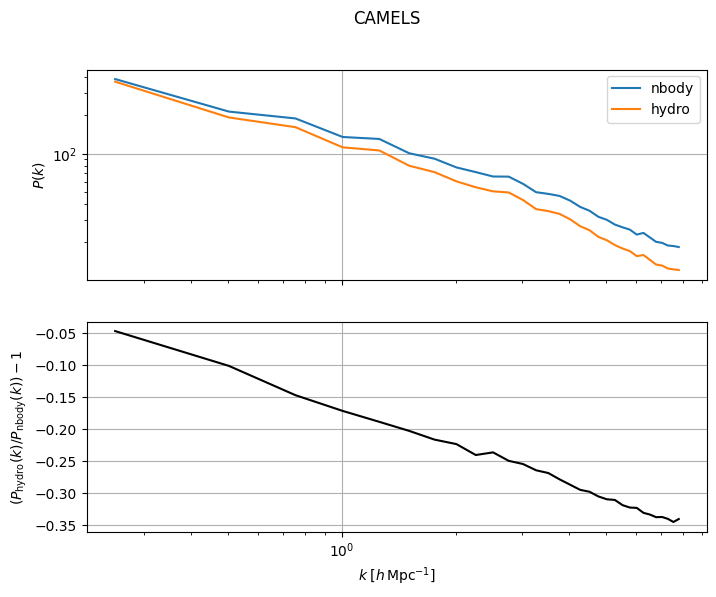

In [21]:
fig, ax = plot_cls(nbody_rho_tot, hydro_rho_tot)
fig.suptitle("CAMELS")

In [16]:
# fig, ax = plt.subplots(figsize=(2*4, 6), nrows=2, sharex="col")

# ax[0].plot(kbins, nbody_cls_tot, label="nbody")
# ax[0].plot(kbins, hydro_cls_tot, label="hydro")

# ax[0].set(xscale="log", ylabel=r"$P(k)$")
# ax[0].legend()
# ax[0].grid(True)

# ax[1].plot(kbins, hydro_cls_tot/nbody_cls_tot-1, color="k")
# ax[1].set(xlabel=r"$k \; [h \, \text{Mpc}^{-1}]$", ylabel=r"$(P_\text{hydro}(k) / P_\text{nbody}(k)) - 1$")
# ax[1].grid(True)

# fig.suptitle("CAMELS");

# Particle Mesh

In [36]:
# build and load model
model = MLP(
    d_in=5, 
    d_out=1, 
    d_hidden=64, 
    n_hidden=4, 
    rngs=nnx.Rngs(0)
)
# checkpoint_file = "/cluster/home/athomsen/flatiron/repos/JaxPM/dev/hpm/sims/checkpoints/hpm_sim_mlp.jx"
# checkpointer = ocp.StandardCheckpointer()
# abstract_model = nnx.eval_shape(lambda: model)
# graphdef, abstract_params = nnx.split(abstract_model)
# params = checkpointer.restore(checkpoint_file, abstract_params)
# model = nnx.merge(graphdef, params)

# run ODE
hpm_ode = hpm.get_hpm_network_ode_fn(model, mesh_shape, cosmo, "diffrax", gravity_only=False)

hpm_res = diffeqsolve(
        terms=ODETerm(hpm_ode),
        solver=LeapfrogMidpoint(),
        t0=hydro_dict["scales"][0],
        t1=hydro_dict["scales"][-1],
        dt0=0.02,
        y0=(hydro_dict["dm_poss"][0], hydro_dict["dm_vels"][0], hydro_dict["gas_poss"][0], hydro_dict["gas_vels"][0]),
        saveat=SaveAt(ts=hydro_dict["scales"]),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

hpm_dm_poss, hpm_dm_vels, hpm_gas_poss, hpm_gas_vels = hpm_res.ys

No latent variable
No latent variable
No latent variable


In [37]:
pm_ode = hpm.get_hpm_network_ode_fn(model, mesh_shape, cosmo, "diffrax", gravity_only=True)

pm_res = diffeqsolve(
        terms=ODETerm(pm_ode),
        solver=LeapfrogMidpoint(),
        t0=hydro_dict["scales"][0],
        t1=hydro_dict["scales"][-1],
        dt0=0.02,
        y0=(hydro_dict["dm_poss"][0], hydro_dict["dm_vels"][0], hydro_dict["gas_poss"][0], hydro_dict["gas_vels"][0]),
        saveat=SaveAt(ts=hydro_dict["scales"]),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

pm_dm_poss, pm_dm_vels, pm_gas_poss, pm_gas_vels = pm_res.ys

In [40]:
pm_rho_tot = cic_paint(jnp.zeros(mesh_shape), pm_dm_poss[i])

hpm_rho_tot = cic_paint(jnp.zeros(mesh_shape), hpm_dm_poss[i], weight=cosmo.Omega_c/(cosmo.Omega_c+cosmo.Omega_b))
hpm_rho_tot += cic_paint(jnp.zeros(mesh_shape), hpm_gas_poss[i], weight=cosmo.Omega_b/(cosmo.Omega_c+cosmo.Omega_b))

kbins, pm_cls_tot = get_cls(pm_rho_tot)
kbins, hpm_cls_tot = get_cls(hpm_rho_tot)

Text(0.5, 0.98, 'PM')

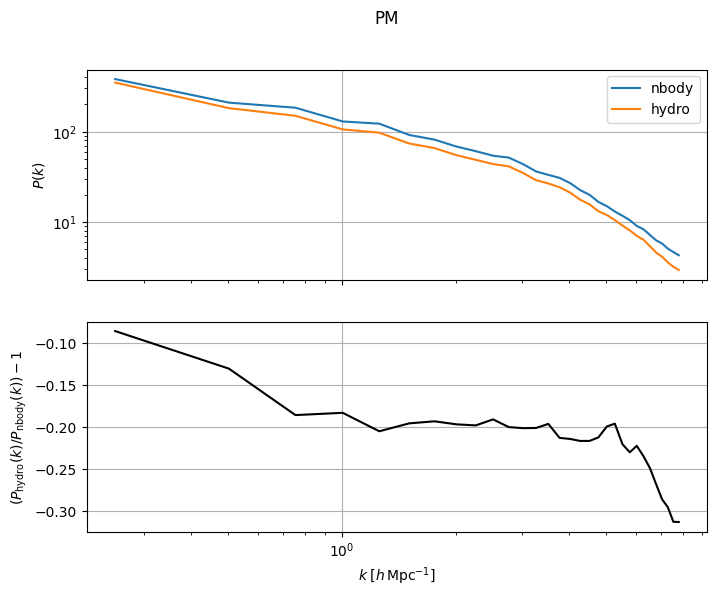

In [41]:
fig, ax = plot_cls(pm_rho_tot, hpm_rho_tot)
fig.suptitle("PM")

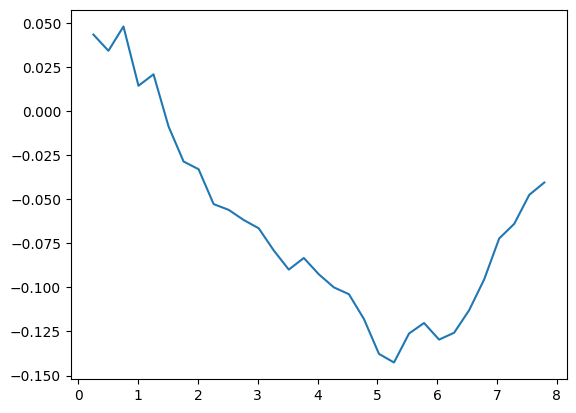

In [44]:
normalized_cls = (hydro_cls_tot / nbody_cls_tot) / (hpm_cls_tot / pm_cls_tot) - 1

fig, ax = plt.subplots()

ax.plot(kbins, normalized_cls)

# trash

In [22]:
hydro_rho_tot = cic_paint(jnp.zeros(mesh_shape), hydro_dict["dm_poss"][i], weight=1 - cosmo.Omega_b / cosmo.Omega_c)
hydro_rho_tot += cic_paint(jnp.zeros(mesh_shape), hydro_dict["gas_poss"][i], weight=cosmo.Omega_b / cosmo.Omega_c)

In [23]:
pm_rho_tot.shape

(64, 64, 64)

NameError: name 'kbins' is not defined

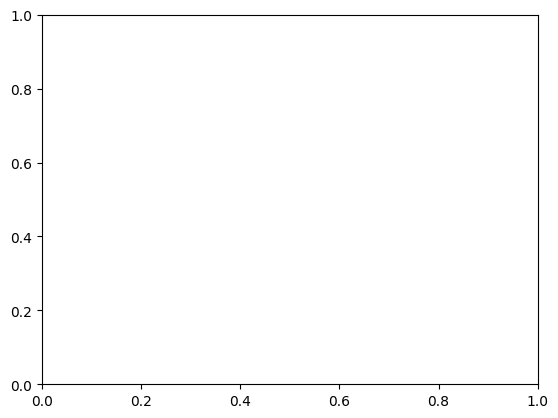

In [24]:
fig, ax = plt.subplots()

ax.plot(kbins, pm_cls_tot, label="nbody")
ax.set(xscale="log")


In [ ]:
fig, ax = plot_cls(nbody_rho_tot, hydro_rho_tot)
fig.suptitle("PM")

In [ ]:
fig, ax = plt.subplots(figsize=(2*4, 6), nrows=2, sharex="col")

ax[0].plot(kbins, nbody_cls_tot, label="nbody")
ax[0].plot(kbins, hydro_cls_tot, label="hydro")

ax[0].set(xscale="log", ylabel=r"$P(k)$")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(kbins, hydro_cls_tot/nbody_cls_tot-1, color="k")
ax[1].set(xlabel=r"$k \; [h \, \text{Mpc}^{-1}]$", ylabel=r"$(P_\text{hydro}(k) / P_\text{nbody}(k)) - 1$")
ax[1].grid(True)

fig.suptitle("CAMELS");

In [ ]:
# hpm_ode = hpm.get_hpm_network_ode_fn(model, mesh_shape, cosmo, "odeint", architecture=architecture)
# # hpm_ode = hpm.get_hpm_network_ode_fn(model, mesh_shape, cosmo, "odeint", force_type="gnn", edges=edges)
# # hpm_ode = lambda state, scale: gnn_hpm_ode(scale, state, None)

# res = odeint(hpm_ode, [dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]], scales, {"gas_latent": jnp.ones(parts_per_dim**3)}, rtol=1e-5, atol=1e-5, mxstep=20)
# # res = odeint(hpm_ode, [dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]], scales, {}, rtol=1e-5, atol=1e-5, mxstep=20)
# hpm_dm_poss, hpm_dm_vels, hpm_gas_poss, hpm_gas_vels = res[0], res[1], res[2], res[3]

In [ ]:
fig, ax = plt.subplots()

ax.plot(kbins, hydro_cls_tot/nbody_cls_tot-1)
ax.set(xscale="log")

In [ ]:
kbins, nbody_cls_tot = get_cls(nbody_rho_tot)
kbins, hydro_cls_tot = get_cls(hydro_rho_tot)

In [ ]:
cosmo = hydro_dict["cosmo"]

In [ ]:
nbody_rho_tot = cic_paint(jnp.zeros(mesh_shape), nbody_dict["dm_poss"])

In [ ]:
hydro_rho_tot = cic_paint(jnp.zeros(mesh_shape), hydro_dict["dm_poss"])
hydro_rho_tot += cic_paint(jnp.zeros(mesh_shape), hydro_dict["gas_poss"], weight=cosmo.Omega_b / cosmo.Omega_c)

In [ ]:
jnp.sum(nbody_rho_tot)

In [ ]:
jnp.sum(hydro_rho_tot)

In [ ]:
kbins, nbody_cls_tot = get_total_matter_spectrum(nbody_dict)
kbins, hydro_cls_tot = get_total_matter_spectrum(hydro_dict)

In [ ]:
dm_pos = dm_dict["dm_poss"]
gas_pos = dm_dict["gas_poss"]

In [ ]:
rho_dm = cic_paint(jnp.zeros(mesh_shape), dm_pos)
rho_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos, weight=cosmo.Omega_b / cosmo.Omega_c)
rho_tot = rho_dm + rho_gas


In [ ]:
# per-particle reference
ref_pos = jnp.stack(gas_poss, axis=0)
ref_vel = jnp.stack(gas_vels, axis=0)

# field-level reference
ref_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, cosmo.Omega_b / cosmo.Omega_c)

    res_rho = vcic_paint(jnp.zeros(mesh_shape), res[2], cosmo.Omega_b / cosmo.Omega_c)
    _, res_cls = vpower_spectrum(res_rho)
    cl_loss = jnp.mean(jnp.sum((res_cls/ref_cls - 1)**2, axis=-1))


In [ ]:
# def get_total_matter_spectrum(snapshot_dict):
#     cosmo = snapshot_dict["cosmo"]
    
#     dm_pos = snapshot_dict["dm_poss"]
#     rho_dm = cic_paint(jnp.zeros(mesh_shape), dm_pos)

#     try:
#         gas_pos = snapshot_dict["gas_poss"]
#         rho_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos, weight=cosmo.Omega_b / cosmo.Omega_c)
#         rho_tot = rho_dm + rho_gas
#     except KeyError:
#         rho_tot = rho_dm

#     kbins, cls_tot = power_spectrum(
#         compensate_cic(rho_tot),
#         boxsize=np.array([boxsize] * 3),
#         kmin=np.pi / boxsize,
#         dk=2 * np.pi / boxsize,
#     )

#     return kbins, cls_tot